# RTI 502 – Deep Learning Assignment 1
## Training and Testing a Neural Network on MNIST Using PyTorch

**Group Number:**  
**Group Members:**  

## Task 1: Install and Import PyTorch

PyTorch and Torchvision were installed successfully inside a Python virtual environment.  
The required libraries are imported in the following code cell, and a fixed random seed is used to make the experiment reproducible.

### Environment Information

- **Python version:** 3.13.15
- **PyTorch version:** 2.14.0+cpu
- **Torchvision version:** 0.29.0+cpu
- **Selected device:** CPU

The CPU is sufficient for training a basic neural network on the MNIST dataset because MNIST is relatively small and contains low-resolution grayscale images.

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", device)
print("PyTorch loaded successfully!")

PyTorch version: 2.14.0+cpu
Torchvision version: 0.29.0+cpu
Device: cpu
PyTorch loaded successfully!


## Task 2: Download and Load the MNIST Dataset

MNIST contains grayscale images of handwritten digits from 0 to 9.  
Each image has a size of 28 × 28 pixels.

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Convert every image into a PyTorch tensor
transform = transforms.ToTensor()

# Download the original MNIST datasets
full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Split the original 60,000 images into:
# 50,000 for training and 10,000 for validation
train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [50000, 10000],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Dataset downloaded and loaded successfully!")
print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Testing images:", len(test_dataset))
print("Batch size:", batch_size)

Dataset downloaded and loaded successfully!
Training images: 50000
Validation images: 10000
Testing images: 10000
Batch size: 32


## Task 3: Inspect and Visualize the Dataset

In [4]:
# Get one batch from the training loader
images, labels = next(iter(train_loader))

print("Images tensor shape:", images.shape)
print("Labels tensor shape:", labels.shape)
print("Tensor data type:", images.dtype)
print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())

# Flatten images while keeping the batch dimension
flattened_images = torch.flatten(images, start_dim=1)
print("Shape after flattening:", flattened_images.shape)

Images tensor shape: torch.Size([32, 1, 28, 28])
Labels tensor shape: torch.Size([32])
Tensor data type: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Shape after flattening: torch.Size([32, 784])


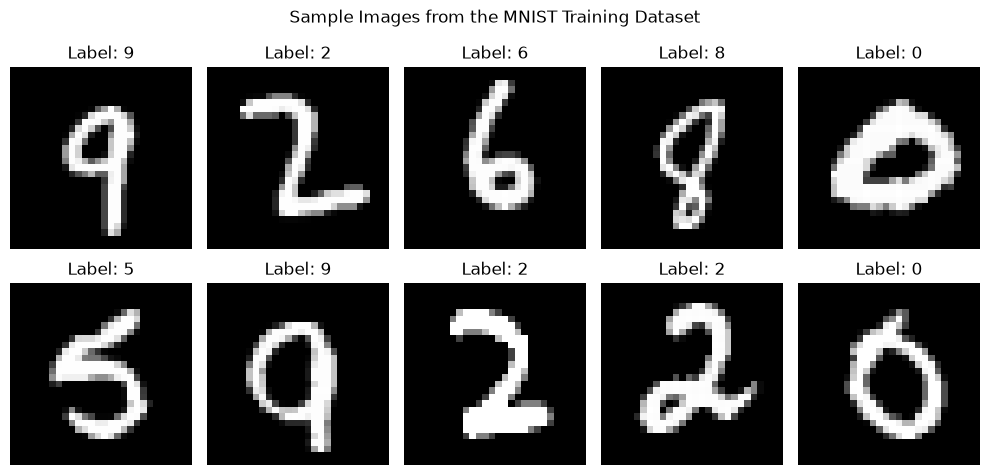

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for index, axis in enumerate(axes.flat):
    axis.imshow(images[index].squeeze(), cmap="gray")
    axis.set_title(f"Label: {labels[index].item()}")
    axis.axis("off")

plt.suptitle("Sample Images from the MNIST Training Dataset")
plt.tight_layout()
plt.show()

## Task 4: Create a Simple Neural Network

The baseline model is a fully connected neural network with one hidden layer.

### Network Architecture

1. The input images are flattened from `1 × 28 × 28` into `784` features.
2. The first fully connected layer maps `784` inputs to `128` hidden neurons.
3. The ReLU activation function introduces non-linearity.
4. The output layer produces `10` logits representing digits from 0 to 9.

Softmax is not included in the model because `CrossEntropyLoss` applies the required operation internally during training.

In [6]:
import torch.nn as nn


class SimpleNeuralNetwork(nn.Module):
    def __init__(self, hidden_neurons=128):
        super().__init__()

        # 784 input features -> hidden neurons
        self.hidden_layer = nn.Linear(28 * 28, hidden_neurons)

        # ReLU activation function
        self.relu = nn.ReLU()

        # Hidden neurons -> 10 digit classes
        self.output_layer = nn.Linear(hidden_neurons, 10)

    def forward(self, x):
        # Convert (N, 1, 28, 28) into (N, 784)
        x = torch.flatten(x, start_dim=1)

        x = self.hidden_layer(x)
        x = self.relu(x)
        x = self.output_layer(x)

        return x


model = SimpleNeuralNetwork(hidden_neurons=128).to(device)

print(model)

SimpleNeuralNetwork(
  (hidden_layer): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
)


In [7]:
sample_images, sample_labels = next(iter(train_loader))

flattened_sample = torch.flatten(sample_images, start_dim=1)

model.eval()
with torch.no_grad():
    sample_outputs = model(sample_images.to(device))

print("Original input shape:", sample_images.shape)
print("Flattened input shape:", flattened_sample.shape)
print("Network output shape:", sample_outputs.shape)
print("Predicted digit for each image:", sample_outputs.argmax(dim=1))

Original input shape: torch.Size([32, 1, 28, 28])
Flattened input shape: torch.Size([32, 784])
Network output shape: torch.Size([32, 10])
Predicted digit for each image: tensor([1, 1, 8, 8, 8, 8, 1, 1, 1, 1, 1, 1, 8, 1, 1, 1, 1, 1, 8, 1, 1, 3, 1, 1,
        8, 1, 1, 8, 8, 8, 8, 8])


## Task 5: Create the Training Function

The training function uses `CrossEntropyLoss` to measure classification error and Stochastic Gradient Descent (SGD) to update the model parameters.

The learning rate controls the size of each parameter update, while momentum helps the optimizer move more consistently toward a better solution.

For every mini-batch, the function performs the following steps:

1. Clear the old gradients.
2. Generate predictions using the network.
3. Calculate the loss.
4. Compute gradients using backpropagation.
5. Update the network parameters.
6. Record the loss and accuracy.

In [8]:
def train_network(
    net,
    train_dataloader,
    epochs=10,
    learning_rate=0.01,
    momentum=0.9,
    print_every=300
):
    # CrossEntropyLoss is suitable for multi-class classification
    criterion = nn.CrossEntropyLoss()

    # SGD optimizer with learning rate and momentum
    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=learning_rate,
        momentum=momentum
    )

    history = {
        "batch_losses": [],
        "epoch_losses": [],
        "epoch_accuracies": []
    }

    for epoch in range(epochs):
        net.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for batch_number, (batch_images, batch_labels) in enumerate(
            train_dataloader,
            start=1
        ):
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            # Step 1: Clear gradients from the previous batch
            optimizer.zero_grad()

            # Step 2: Forward pass
            outputs = net(batch_images)

            # Step 3: Calculate loss
            loss = criterion(outputs, batch_labels)

            # Step 4: Backpropagation
            loss.backward()

            # Step 5: Update model parameters
            optimizer.step()

            # Calculate predictions and batch accuracy
            predictions = outputs.argmax(dim=1)
            batch_correct = (predictions == batch_labels).sum().item()
            batch_accuracy = 100 * batch_correct / batch_labels.size(0)

            # Store training statistics
            history["batch_losses"].append(loss.item())
            total_loss += loss.item() * batch_labels.size(0)
            total_correct += batch_correct
            total_samples += batch_labels.size(0)

            # Print debug information
            if (
                batch_number == 1
                or batch_number % print_every == 0
                or batch_number == len(train_dataloader)
            ):
                print(
                    f"Epoch [{epoch + 1}/{epochs}] "
                    f"Batch [{batch_number}/{len(train_dataloader)}] "
                    f"Loss: {loss.item():.4f} "
                    f"Accuracy: {batch_accuracy:.2f}%"
                )

        epoch_loss = total_loss / total_samples
        epoch_accuracy = 100 * total_correct / total_samples

        history["epoch_losses"].append(epoch_loss)
        history["epoch_accuracies"].append(epoch_accuracy)

        print(
            f"Epoch {epoch + 1} completed | "
            f"Average Loss: {epoch_loss:.4f} | "
            f"Training Accuracy: {epoch_accuracy:.2f}%\n"
        )

    return history

## Task 6: Train the Neural Network

A new instance of the neural network is created and trained on 50,000 MNIST training images.

### Baseline Training Configuration

- **Hidden neurons:** 128
- **Epochs:** 10
- **Batch size:** 32
- **Learning rate:** 0.01
- **Momentum:** 0.9
- **Loss function:** CrossEntropyLoss
- **Optimizer:** Stochastic Gradient Descent (SGD)

During training, the epoch number, batch number, current loss, and current accuracy are displayed. Mini-batch and epoch statistics are also stored for visualization.

In [9]:
# Fix the random seed for reproducible initialization
torch.manual_seed(SEED)

# Instantiate a new network
trained_model = SimpleNeuralNetwork(hidden_neurons=128).to(device)

epochs = 10
learning_rate = 0.01
momentum = 0.9

print("Training configuration")
print("----------------------")
print("Model:", trained_model)
print("Device:", device)
print("Epochs:", epochs)
print("Batch size:", batch_size)
print("Learning rate:", learning_rate)
print("Momentum:", momentum)
print()

training_history = train_network(
    net=trained_model,
    train_dataloader=train_loader,
    epochs=epochs,
    learning_rate=learning_rate,
    momentum=momentum,
    print_every=300
)

Training configuration
----------------------
Model: SimpleNeuralNetwork(
  (hidden_layer): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
)
Device: cpu
Epochs: 10
Batch size: 32
Learning rate: 0.01
Momentum: 0.9

Epoch [1/10] Batch [1/1563] Loss: 2.2597 Accuracy: 15.62%
Epoch [1/10] Batch [300/1563] Loss: 0.4150 Accuracy: 84.38%
Epoch [1/10] Batch [600/1563] Loss: 0.6858 Accuracy: 81.25%
Epoch [1/10] Batch [900/1563] Loss: 0.1951 Accuracy: 90.62%
Epoch [1/10] Batch [1200/1563] Loss: 0.2211 Accuracy: 93.75%
Epoch [1/10] Batch [1500/1563] Loss: 0.1850 Accuracy: 93.75%
Epoch [1/10] Batch [1563/1563] Loss: 0.1836 Accuracy: 93.75%
Epoch 1 completed | Average Loss: 0.3833 | Training Accuracy: 88.97%

Epoch [2/10] Batch [1/1563] Loss: 0.4131 Accuracy: 84.38%
Epoch [2/10] Batch [300/1563] Loss: 0.0586 Accuracy: 100.00%
Epoch [2/10] Batch [600/1563] Loss: 0.1361 Accuracy: 96.88%
Epoch [2/10] Batch [900

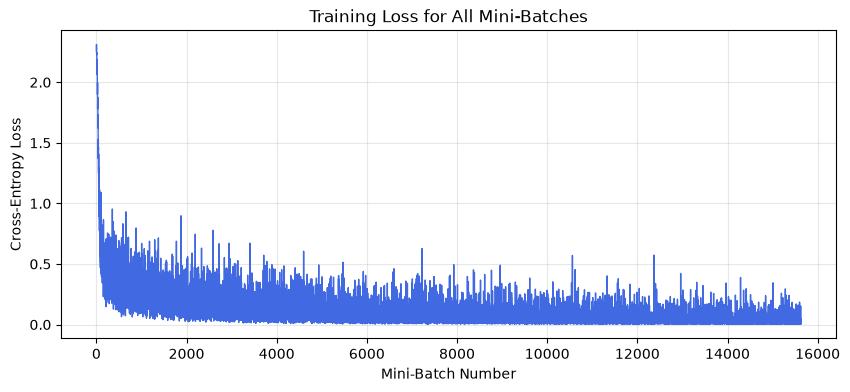

In [11]:
plt.figure(figsize=(10, 4))

plt.plot(
    training_history["batch_losses"],
    color="royalblue",
    linewidth=1
)

plt.title("Training Loss for All Mini-Batches")
plt.xlabel("Mini-Batch Number")
plt.ylabel("Cross-Entropy Loss")
plt.grid(alpha=0.3)
plt.show()

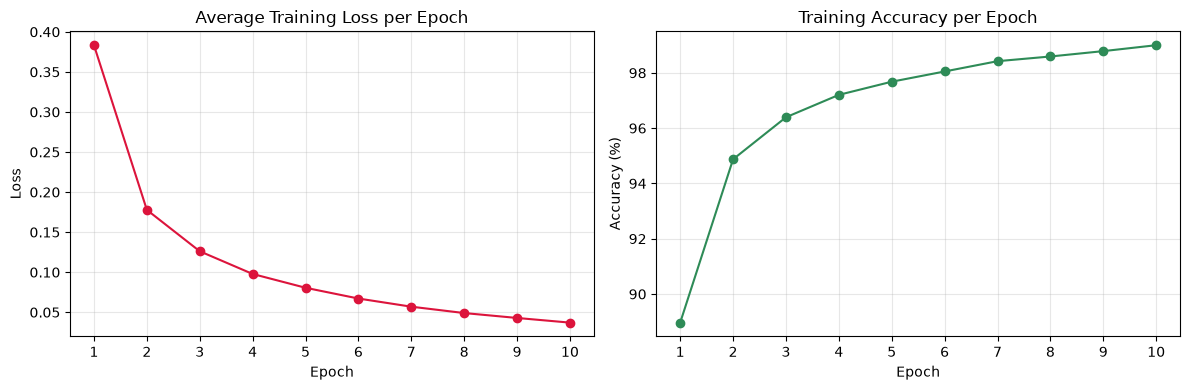

In [10]:
epoch_numbers = range(
    1,
    len(training_history["epoch_losses"]) + 1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Average loss for each epoch
axes[0].plot(
    epoch_numbers,
    training_history["epoch_losses"],
    marker="o",
    color="crimson"
)
axes[0].set_title("Average Training Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(list(epoch_numbers))
axes[0].grid(alpha=0.3)

# Training accuracy for each epoch
axes[1].plot(
    epoch_numbers,
    training_history["epoch_accuracies"],
    marker="o",
    color="seagreen"
)
axes[1].set_title("Training Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_xticks(list(epoch_numbers))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Task 7: Test the Neural Network

The trained network is evaluated using the separate MNIST test dataset. These images were not used to update the model parameters during training.

The test loss and accuracy are calculated across all 10,000 test images. Several test images are also displayed with their actual and predicted labels.

In [12]:
def test_network(net, test_dataloader):
    criterion = nn.CrossEntropyLoss()

    net.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for test_images, test_labels in test_dataloader:
            test_images = test_images.to(device)
            test_labels = test_labels.to(device)

            outputs = net(test_images)
            loss = criterion(outputs, test_labels)

            predictions = outputs.argmax(dim=1)

            total_loss += loss.item() * test_labels.size(0)
            total_correct += (predictions == test_labels).sum().item()
            total_samples += test_labels.size(0)

    average_test_loss = total_loss / total_samples
    test_accuracy = 100 * total_correct / total_samples

    return average_test_loss, test_accuracy

In [13]:
test_loss, test_accuracy = test_network(
    trained_model,
    test_loader
)

print("Test Results")
print("------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Correct Predictions: {int(test_accuracy / 100 * len(test_dataset))}")
print(f"Total Test Images: {len(test_dataset)}")

Test Results
------------
Test Loss: 0.0740
Test Accuracy: 97.64%
Correct Predictions: 9764
Total Test Images: 10000


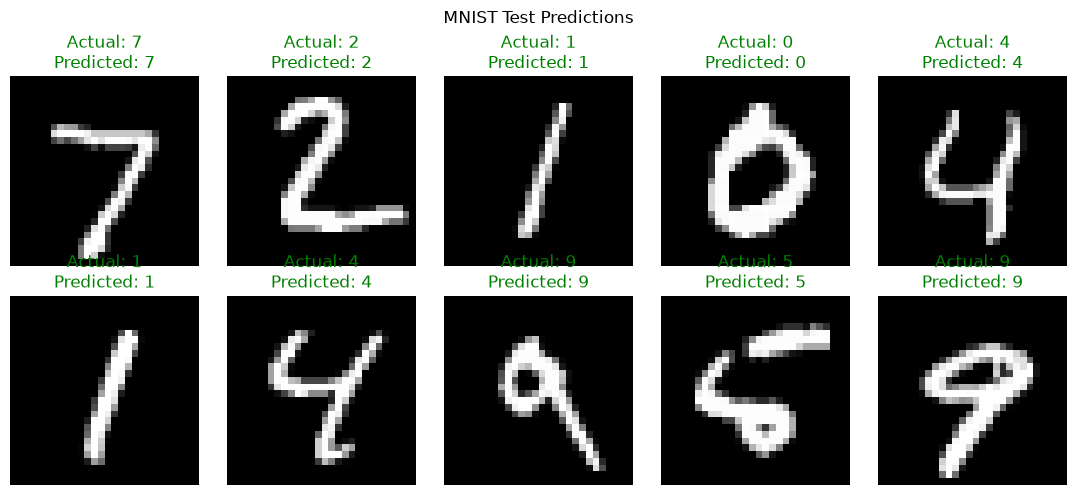

In [15]:
test_images, test_labels = next(iter(test_loader))

trained_model.eval()

with torch.no_grad():
    outputs = trained_model(test_images.to(device))
    predicted_labels = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(11, 5))

for index, axis in enumerate(axes.flat):
    actual = test_labels[index].item()
    predicted = predicted_labels[index].item()

    axis.imshow(test_images[index].squeeze(), cmap="gray")
    axis.set_title(
        f"Actual: {actual}\nPredicted: {predicted}",
        color="green" if actual == predicted else "red"
    )
    axis.axis("off")

plt.suptitle("MNIST Test Predictions")
plt.tight_layout()
plt.show()

## Task 8: Hyperparameter and Architecture Tuning

Several experiments are conducted to study the effects of:

- Learning rate
- Momentum
- Number of hidden layers
- Number of neurons

Each candidate model is evaluated using the validation dataset. The test dataset is kept separate until the best configuration has been selected.

In [16]:
class TunableNeuralNetwork(nn.Module):
    def __init__(self, hidden_layers):
        super().__init__()

        layers = [nn.Flatten()]
        input_features = 28 * 28

        for neurons in hidden_layers:
            layers.append(nn.Linear(input_features, neurons))
            layers.append(nn.ReLU())
            input_features = neurons

        layers.append(nn.Linear(input_features, 10))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [17]:
tuning_configurations = [
    {
        "name": "No Momentum",
        "hidden_layers": [128],
        "learning_rate": 0.01,
        "momentum": 0.0
    },
    {
        "name": "With Momentum",
        "hidden_layers": [128],
        "learning_rate": 0.01,
        "momentum": 0.9
    },
    {
        "name": "Higher Learning Rate",
        "hidden_layers": [128],
        "learning_rate": 0.03,
        "momentum": 0.9
    },
    {
        "name": "More Neurons",
        "hidden_layers": [256],
        "learning_rate": 0.03,
        "momentum": 0.9
    },
    {
        "name": "Two Hidden Layers",
        "hidden_layers": [512, 256],
        "learning_rate": 0.03,
        "momentum": 0.9
    }
]

In [18]:
tuning_results = []

for experiment_number, config in enumerate(
    tuning_configurations,
    start=1
):
    print("=" * 65)
    print(
        f"Experiment {experiment_number}: {config['name']}"
    )
    print(
        f"Layers: {config['hidden_layers']} | "
        f"Learning rate: {config['learning_rate']} | "
        f"Momentum: {config['momentum']}"
    )
    print("=" * 65)

    torch.manual_seed(SEED)

    candidate_model = TunableNeuralNetwork(
        hidden_layers=config["hidden_layers"]
    ).to(device)

    candidate_history = train_network(
        net=candidate_model,
        train_dataloader=train_loader,
        epochs=3,
        learning_rate=config["learning_rate"],
        momentum=config["momentum"],
        print_every=len(train_loader)
    )

    validation_loss, validation_accuracy = test_network(
        candidate_model,
        validation_loader
    )

    tuning_results.append({
        "name": config["name"],
        "hidden_layers": config["hidden_layers"],
        "learning_rate": config["learning_rate"],
        "momentum": config["momentum"],
        "validation_loss": validation_loss,
        "validation_accuracy": validation_accuracy
    })

    print(
        f"Validation Loss: {validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy:.2f}%\n"
    )

Experiment 1: No Momentum
Layers: [128] | Learning rate: 0.01 | Momentum: 0.0
Epoch [1/3] Batch [1/1563] Loss: 2.2597 Accuracy: 15.62%
Epoch [1/3] Batch [1563/1563] Loss: 0.4586 Accuracy: 81.25%
Epoch 1 completed | Average Loss: 0.9389 | Training Accuracy: 78.74%

Epoch [2/3] Batch [1/1563] Loss: 0.6890 Accuracy: 75.00%
Epoch [2/3] Batch [1563/1563] Loss: 0.5906 Accuracy: 75.00%
Epoch 2 completed | Average Loss: 0.3986 | Training Accuracy: 89.09%

Epoch [3/3] Batch [1/1563] Loss: 0.3642 Accuracy: 93.75%
Epoch [3/3] Batch [1563/1563] Loss: 0.1950 Accuracy: 100.00%
Epoch 3 completed | Average Loss: 0.3374 | Training Accuracy: 90.46%

Validation Loss: 0.3292 | Validation Accuracy: 90.58%

Experiment 2: With Momentum
Layers: [128] | Learning rate: 0.01 | Momentum: 0.9
Epoch [1/3] Batch [1/1563] Loss: 2.2597 Accuracy: 15.62%
Epoch [1/3] Batch [1563/1563] Loss: 0.1836 Accuracy: 93.75%
Epoch 1 completed | Average Loss: 0.3833 | Training Accuracy: 88.97%

Epoch [2/3] Batch [1/1563] Loss: 0.413

In [19]:
sorted_results = sorted(
    tuning_results,
    key=lambda result: (
        -result["validation_accuracy"],
        result["validation_loss"]
    )
)

print("Tuning Results")
print("=" * 95)
print(
    f"{'Experiment':<22}"
    f"{'Layers':<16}"
    f"{'LR':<10}"
    f"{'Momentum':<12}"
    f"{'Val Loss':<12}"
    f"{'Val Accuracy'}"
)
print("-" * 95)

for result in sorted_results:
    print(
        f"{result['name']:<22}"
        f"{str(result['hidden_layers']):<16}"
        f"{result['learning_rate']:<10}"
        f"{result['momentum']:<12}"
        f"{result['validation_loss']:<12.4f}"
        f"{result['validation_accuracy']:.2f}%"
    )

best_configuration = sorted_results[0]

print("\nBest configuration:")
print(best_configuration)

Tuning Results
Experiment            Layers          LR        Momentum    Val Loss    Val Accuracy
-----------------------------------------------------------------------------------------------
Two Hidden Layers     [512, 256]      0.03      0.9         0.0899      97.19%
More Neurons          [256]           0.03      0.9         0.0907      97.11%
Higher Learning Rate  [128]           0.03      0.9         0.1047      96.84%
With Momentum         [128]           0.01      0.9         0.1373      96.04%
No Momentum           [128]           0.01      0.0         0.3292      90.58%

Best configuration:
{'name': 'Two Hidden Layers', 'hidden_layers': [512, 256], 'learning_rate': 0.03, 'momentum': 0.9, 'validation_loss': 0.08988297107629478, 'validation_accuracy': 97.19}


### Tuning Results Analysis

Momentum produced a major improvement in validation accuracy, increasing it from **90.58%** to **96.04%**. Increasing the learning rate from 0.01 to 0.03 further improved the result to **96.84%**.

Increasing the number of hidden neurons achieved **97.11%**, while using two hidden layers with 512 and 256 neurons produced the best validation result of **97.19%** and the lowest validation loss of **0.0899**.

These experiments demonstrate that learning rate, momentum, depth, and the number of neurons all influence neural network performance.

### Advanced Architecture: Convolutional Neural Network

An additional CNN architecture is evaluated because convolutional layers preserve the spatial relationships between neighboring pixels. This makes CNNs particularly effective for image classification.

In [20]:
from torch.utils.data import DataLoader, Subset
import copy

cnn_train_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=8,
        translate=(0.08, 0.08)
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

cnn_evaluation_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

augmented_full_training = datasets.MNIST(
    root="./data",
    train=True,
    download=False,
    transform=cnn_train_transform
)

normalized_full_training = datasets.MNIST(
    root="./data",
    train=True,
    download=False,
    transform=cnn_evaluation_transform
)

cnn_test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=False,
    transform=cnn_evaluation_transform
)

cnn_train_dataset = Subset(
    augmented_full_training,
    train_dataset.indices
)

cnn_validation_dataset = Subset(
    normalized_full_training,
    validation_dataset.indices
)

cnn_train_loader = DataLoader(
    cnn_train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

cnn_validation_loader = DataLoader(
    cnn_validation_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

cnn_test_loader = DataLoader(
    cnn_test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

print("CNN training images:", len(cnn_train_dataset))
print("CNN validation images:", len(cnn_validation_dataset))
print("CNN testing images:", len(cnn_test_dataset))

CNN training images: 50000
CNN validation images: 10000
CNN testing images: 10000


In [21]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


cnn_model = MNISTCNN().to(device)
print(cnn_model)

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=3136, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.25, inplace=False

In [22]:
def train_cnn(
    net,
    train_dataloader,
    validation_dataloader,
    epochs=12,
    learning_rate=0.05,
    momentum=0.9
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=learning_rate,
        momentum=momentum,
        weight_decay=0.0005,
        nesterov=True
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=0.001
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": []
    }

    best_validation_accuracy = 0.0
    best_model_state = None

    for epoch in range(epochs):
        net.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for images, labels in train_dataloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = net(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            predictions = outputs.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = total_loss / total_samples
        train_accuracy = 100 * total_correct / total_samples

        validation_loss, validation_accuracy = test_network(
            net,
            validation_dataloader
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"LR: {current_lr:.5f} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.2f}% | "
            f"Validation Loss: {validation_loss:.4f} | "
            f"Validation Accuracy: {validation_accuracy:.2f}%"
        )

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            best_model_state = copy.deepcopy(net.state_dict())

        scheduler.step()

    net.load_state_dict(best_model_state)

    print(
        f"\nBest Validation Accuracy: "
        f"{best_validation_accuracy:.2f}%"
    )

    return history

In [23]:
# Get one batch from the training loader
images, labels = next(iter(train_loader))

print("Images tensor shape:", images.shape)
print("Labels tensor shape:", labels.shape)
print("Tensor data type:", images.dtype)
print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())

# Flatten images while keeping the batch dimension
flattened_images = torch.flatten(images, start_dim=1)
print("Shape after flattening:", flattened_images.shape)

Images tensor shape: torch.Size([32, 1, 28, 28])
Labels tensor shape: torch.Size([32])
Tensor data type: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Shape after flattening: torch.Size([32, 784])


In [24]:
torch.manual_seed(SEED)

cnn_model = MNISTCNN().to(device)

cnn_history = train_cnn(
    net=cnn_model,
    train_dataloader=cnn_train_loader,
    validation_dataloader=cnn_validation_loader,
    epochs=12,
    learning_rate=0.05,
    momentum=0.9
)

Epoch [1/12] | LR: 0.05000 | Train Loss: 0.2862 | Train Accuracy: 91.01% | Validation Loss: 0.0634 | Validation Accuracy: 98.07%
Epoch [2/12] | LR: 0.04917 | Train Loss: 0.0934 | Train Accuracy: 97.26% | Validation Loss: 0.0357 | Validation Accuracy: 98.98%
Epoch [3/12] | LR: 0.04672 | Train Loss: 0.0735 | Train Accuracy: 97.79% | Validation Loss: 0.0281 | Validation Accuracy: 99.11%
Epoch [4/12] | LR: 0.04282 | Train Loss: 0.0583 | Train Accuracy: 98.35% | Validation Loss: 0.0274 | Validation Accuracy: 99.09%
Epoch [5/12] | LR: 0.03775 | Train Loss: 0.0540 | Train Accuracy: 98.31% | Validation Loss: 0.0246 | Validation Accuracy: 99.28%
Epoch [6/12] | LR: 0.03184 | Train Loss: 0.0456 | Train Accuracy: 98.59% | Validation Loss: 0.0322 | Validation Accuracy: 99.07%
Epoch [7/12] | LR: 0.02550 | Train Loss: 0.0408 | Train Accuracy: 98.68% | Validation Loss: 0.0246 | Validation Accuracy: 99.23%
Epoch [8/12] | LR: 0.01916 | Train Loss: 0.0360 | Train Accuracy: 98.96% | Validation Loss: 0.021

In [25]:
torch.save(
    cnn_model.state_dict(),
    "cnn_seed42_best.pth"
)

print("First CNN saved successfully.")

First CNN saved successfully.


In [26]:
SECOND_SEED = 2026

random.seed(SECOND_SEED)
np.random.seed(SECOND_SEED)
torch.manual_seed(SECOND_SEED)

cnn_model_2 = MNISTCNN().to(device)

cnn_history_2 = train_cnn(
    net=cnn_model_2,
    train_dataloader=cnn_train_loader,
    validation_dataloader=cnn_validation_loader,
    epochs=12,
    learning_rate=0.05,
    momentum=0.9
)

Epoch [1/12] | LR: 0.05000 | Train Loss: 0.2600 | Train Accuracy: 91.79% | Validation Loss: 0.0715 | Validation Accuracy: 97.93%
Epoch [2/12] | LR: 0.04917 | Train Loss: 0.0895 | Train Accuracy: 97.26% | Validation Loss: 0.0488 | Validation Accuracy: 98.42%
Epoch [3/12] | LR: 0.04672 | Train Loss: 0.0684 | Train Accuracy: 97.94% | Validation Loss: 0.0328 | Validation Accuracy: 99.02%
Epoch [4/12] | LR: 0.04282 | Train Loss: 0.0569 | Train Accuracy: 98.33% | Validation Loss: 0.0357 | Validation Accuracy: 99.02%
Epoch [5/12] | LR: 0.03775 | Train Loss: 0.0495 | Train Accuracy: 98.53% | Validation Loss: 0.0249 | Validation Accuracy: 99.26%
Epoch [6/12] | LR: 0.03184 | Train Loss: 0.0443 | Train Accuracy: 98.59% | Validation Loss: 0.0232 | Validation Accuracy: 99.27%
Epoch [7/12] | LR: 0.02550 | Train Loss: 0.0368 | Train Accuracy: 98.90% | Validation Loss: 0.0242 | Validation Accuracy: 99.25%
Epoch [8/12] | LR: 0.01916 | Train Loss: 0.0343 | Train Accuracy: 98.98% | Validation Loss: 0.025

In [27]:
torch.save(
    cnn_model_2.state_dict(),
    "cnn_seed2026_best.pth"
)

print("Second CNN saved successfully.")

Second CNN saved successfully.


In [28]:
def evaluate_ensemble(models, dataloader):
    criterion = nn.CrossEntropyLoss()

    for model in models:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            model_outputs = [
                model(images) for model in models
            ]

            averaged_outputs = torch.stack(
                model_outputs,
                dim=0
            ).mean(dim=0)

            loss = criterion(averaged_outputs, labels)
            predictions = averaged_outputs.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)
            total_correct += (
                predictions == labels
            ).sum().item()
            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = 100 * total_correct / total_samples

    return average_loss, accuracy

In [29]:
model_1_val_loss, model_1_val_accuracy = test_network(
    cnn_model,
    cnn_validation_loader
)

model_2_val_loss, model_2_val_accuracy = test_network(
    cnn_model_2,
    cnn_validation_loader
)

ensemble_val_loss, ensemble_val_accuracy = evaluate_ensemble(
    models=[cnn_model, cnn_model_2],
    dataloader=cnn_validation_loader
)

print("Validation Comparison")
print("---------------------")
print(
    f"CNN 1:    Loss = {model_1_val_loss:.4f}, "
    f"Accuracy = {model_1_val_accuracy:.2f}%"
)
print(
    f"CNN 2:    Loss = {model_2_val_loss:.4f}, "
    f"Accuracy = {model_2_val_accuracy:.2f}%"
)
print(
    f"Ensemble: Loss = {ensemble_val_loss:.4f}, "
    f"Accuracy = {ensemble_val_accuracy:.2f}%"
)

Validation Comparison
---------------------
CNN 1:    Loss = 0.0163, Accuracy = 99.47%
CNN 2:    Loss = 0.0154, Accuracy = 99.43%
Ensemble: Loss = 0.0149, Accuracy = 99.45%


In [30]:
def evaluate_weighted_ensemble(
    model_1,
    model_2,
    dataloader,
    model_1_weight
):
    criterion = nn.CrossEntropyLoss()

    model_1.eval()
    model_2.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs_1 = model_1(images)
            outputs_2 = model_2(images)

            combined_outputs = (
                model_1_weight * outputs_1
                + (1 - model_1_weight) * outputs_2
            )

            loss = criterion(combined_outputs, labels)
            predictions = combined_outputs.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)
            total_correct += (
                predictions == labels
            ).sum().item()
            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = 100 * total_correct / total_samples

    return average_loss, accuracy

In [31]:
weight_results = []

for model_1_weight in [
    0.0, 0.1, 0.2, 0.3, 0.4,
    0.5, 0.6, 0.7, 0.8, 0.9, 1.0
]:
    loss, accuracy = evaluate_weighted_ensemble(
        model_1=cnn_model,
        model_2=cnn_model_2,
        dataloader=cnn_validation_loader,
        model_1_weight=model_1_weight
    )

    weight_results.append({
        "model_1_weight": model_1_weight,
        "loss": loss,
        "accuracy": accuracy
    })

    print(
        f"CNN 1 weight: {model_1_weight:.1f} | "
        f"CNN 2 weight: {1 - model_1_weight:.1f} | "
        f"Loss: {loss:.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

best_weight_result = sorted(
    weight_results,
    key=lambda result: (
        -result["accuracy"],
        result["loss"]
    )
)[0]

print("\nBest weighted configuration:")
print(best_weight_result)

CNN 1 weight: 0.0 | CNN 2 weight: 1.0 | Loss: 0.0154 | Accuracy: 99.43%
CNN 1 weight: 0.1 | CNN 2 weight: 0.9 | Loss: 0.0152 | Accuracy: 99.42%
CNN 1 weight: 0.2 | CNN 2 weight: 0.8 | Loss: 0.0150 | Accuracy: 99.47%
CNN 1 weight: 0.3 | CNN 2 weight: 0.7 | Loss: 0.0149 | Accuracy: 99.48%
CNN 1 weight: 0.4 | CNN 2 weight: 0.6 | Loss: 0.0148 | Accuracy: 99.46%
CNN 1 weight: 0.5 | CNN 2 weight: 0.5 | Loss: 0.0149 | Accuracy: 99.45%
CNN 1 weight: 0.6 | CNN 2 weight: 0.4 | Loss: 0.0150 | Accuracy: 99.47%
CNN 1 weight: 0.7 | CNN 2 weight: 0.3 | Loss: 0.0152 | Accuracy: 99.46%
CNN 1 weight: 0.8 | CNN 2 weight: 0.2 | Loss: 0.0154 | Accuracy: 99.47%
CNN 1 weight: 0.9 | CNN 2 weight: 0.1 | Loss: 0.0158 | Accuracy: 99.47%
CNN 1 weight: 1.0 | CNN 2 weight: 0.0 | Loss: 0.0163 | Accuracy: 99.47%

Best weighted configuration:
{'model_1_weight': 0.3, 'loss': 0.01485986737832427, 'accuracy': 99.48}


In [32]:
best_model_1_weight = best_weight_result["model_1_weight"]

final_test_loss, final_test_accuracy = evaluate_weighted_ensemble(
    model_1=cnn_model,
    model_2=cnn_model_2,
    dataloader=cnn_test_loader,
    model_1_weight=best_model_1_weight
)

correct_predictions = round(
    final_test_accuracy / 100 * len(cnn_test_dataset)
)

print("Final Test Results")
print("------------------")
print(f"CNN 1 Weight: {best_model_1_weight:.1f}")
print(f"CNN 2 Weight: {1 - best_model_1_weight:.1f}")
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_accuracy:.2f}%")
print(
    f"Correct Predictions: "
    f"{correct_predictions}/{len(cnn_test_dataset)}"
)

Final Test Results
------------------
CNN 1 Weight: 0.3
CNN 2 Weight: 0.7
Test Loss: 0.0107
Test Accuracy: 99.63%
Correct Predictions: 9963/10000


### Final Advanced Model Results

The weighted CNN ensemble achieved a final test loss of **0.0107** and a test accuracy of **99.63%**, correctly classifying **9,963 out of 10,000** unseen MNIST test images.

The ensemble combines two independently trained CNN models. Based on validation performance, the first model was assigned a weight of **0.3**, while the second model was assigned a weight of **0.7**.

Compared with the baseline fully connected network, the test accuracy increased from **97.64%** to **99.63%**. The number of incorrect predictions decreased from **236** to only **37**, representing an error reduction of approximately **84.3%**.

The results demonstrate that convolutional layers, data augmentation, learning-rate scheduling, and model ensembling can substantially improve image-classification performance.

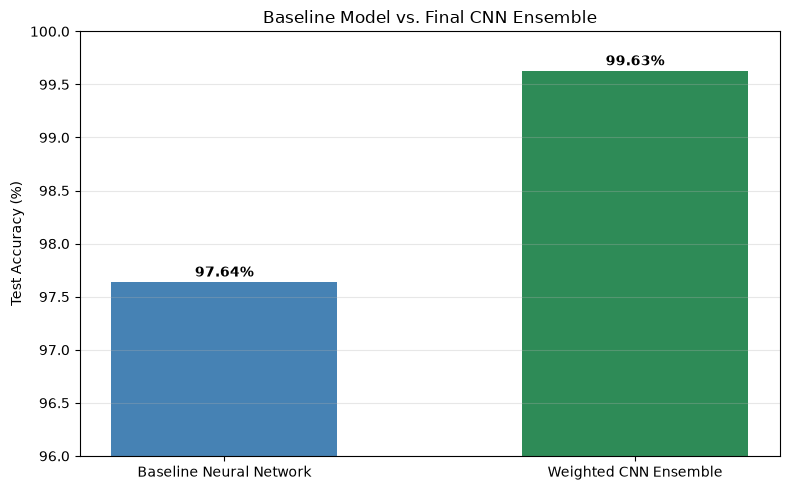

In [33]:
model_names = [
    "Baseline Neural Network",
    "Weighted CNN Ensemble"
]

test_accuracies = [
    test_accuracy,
    final_test_accuracy
]

colors = ["steelblue", "seagreen"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    model_names,
    test_accuracies,
    color=colors,
    width=0.55
)

plt.ylim(96, 100)
plt.ylabel("Test Accuracy (%)")
plt.title("Baseline Model vs. Final CNN Ensemble")
plt.grid(axis="y", alpha=0.3)

for bar, accuracy in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 0.05,
        f"{accuracy:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()